# HR Segmentation Analysis

## Load data

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/processed/HRDataset_v14_engineered.csv")

In [4]:
df.head()

,employee_name,employee_id,married_id,marital_status_id,gender_id,emp_status_id,dept_id,perf_score_id,from_diversity_job_fair_id,salary,...,age,years_since_review,age_at_hire,tenure_days,tenure_years,months_since_review,generation,absent_rate,lateness_flag,high_engagement_flag
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,36.476386,0.952772,27.986311,3101,8.490075,11.433265,Millennials,0.117785,True,False
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,44.657084,3.849418,39.901437,444,1.215606,46.193018,Generation X,13.984797,True,False
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,31.279945,7.627652,22.789870,447,1.223819,91.531828,Millennials,2.451342,True,False
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,31.258042,0.991102,19.277207,4376,11.980835,11.893224,Millennials,1.252000,True,False
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,30.310746,3.912389,21.837098,1884,5.158111,46.948665,Millennials,0.387739,True,False


## Clustering employees

### hdbscan

In [5]:
# keep numeric columns only
numeric_cols = df.select_dtypes(include=["number"]).columns
df_numeric = df[numeric_cols]

In [6]:
df_numeric.columns

Index(['employee_id', 'married_id', 'marital_status_id', 'gender_id',
       'emp_status_id', 'dept_id', 'perf_score_id',
       'from_diversity_job_fair_id', 'salary', 'termd', 'position_id', 'zip',
       'manager_id', 'engagement_survey', 'emp_satisfaction',
       'special_projects_count', 'days_late_last_30', 'absences',
       'quality_of_hire', 'tenure', 'salary_relative_to_dept', 'promoted',
       'age', 'years_since_review', 'age_at_hire', 'tenure_days',
       'tenure_years', 'months_since_review', 'absent_rate'],
      dtype='object')

In [7]:
# use HDBSCAN for clustering
from hdbscan import HDBSCAN


clusterer = HDBSCAN(min_cluster_size=15, min_samples=5)
cluster_labels = clusterer.fit_predict(df_numeric)
df["cluster"] = cluster_labels

### visualize

/Users/jonathan/git_repos/hr-analytics-intelligence/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


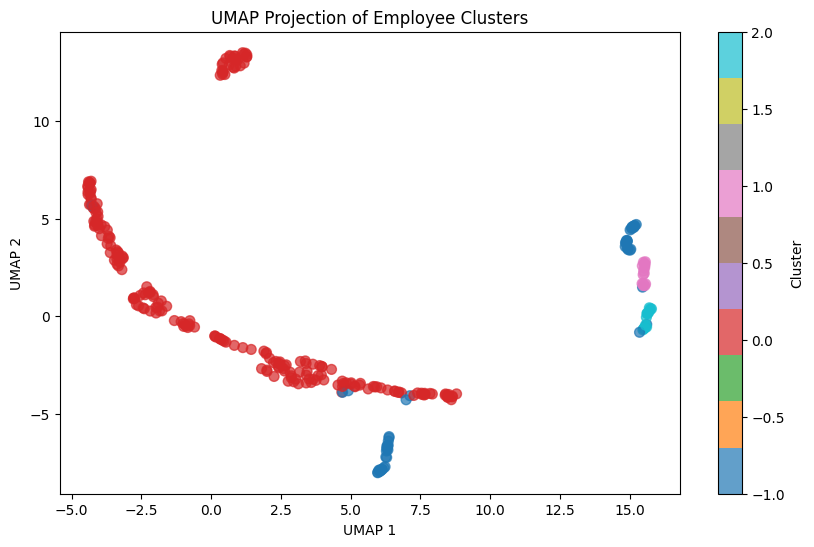

In [8]:
# use UMAP to visualize clusters (discrete coloring by cluster)
import umap


reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(df_numeric)

import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], c=df["cluster"], cmap="tab10", s=50, alpha=0.7)
plt.colorbar(label="Cluster")
plt.title("UMAP Projection of Employee Clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

## Cluster analysis

In [9]:
# how many employees per cluster, and how many are "noise" (-1)?
print(df["cluster"].value_counts().sort_index())

# noise ratio - if > 20%, consider tuning min_cluster_size / min_samples
noise_pct = (df["cluster"] == -1).mean() * 100
print(f"Noise points: {noise_pct:.1f}%")

cluster
-1     53
 0    226
 1     16
 2     16
Name: count, dtype: int64
Noise points: 17.0%


In [ ]:
outcome_cols = ["termd", "high_engagement_flag", "engagement_survey",
                "absences", "days_late_last_30", "salary", "promoted"]

cluster_outcomes = (
    df[df["cluster"] != -1]
    .groupby("cluster")[outcome_cols]
    .agg(["mean", "median"])
    .round(3)
)
print(cluster_outcomes)

         termd        high_engagement_flag        engagement_survey         \
          mean median                 mean median              mean median   
cluster                                                                      
0        0.372    0.0                0.071    0.0             4.120  4.245   
1        0.188    0.0                0.688    1.0             4.184  4.470   
2        0.250    0.0                0.625    1.0             3.888  4.015   

        absences        days_late_last_30            salary          promoted  \
            mean median              mean median       mean   median     mean   
cluster                                                                         
0         10.133   10.5             0.460    0.0  59297.323  59600.0    0.040   
1         10.500    8.5             0.250    0.0  96561.250  96370.0    0.062   
2          9.312   10.0             0.188    0.0  86200.812  86889.5    0.125   

                
        median  
cluster   

Cluster 0 appears to be "at-risk" with highest attrition, low engagement, and highest lateness

Cluster 1 appears to contain highest earners and lowest attrition overall

Cluster 2 is a mixture, likely of progressing employees